In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.2f}'.format)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [6]:
# Descargar precio del Brent
brent = yf.download("BZ=F", start="2010-01-01", end="2026-12-31")

# Quedarnos solo con el precio de cierre
brent = brent[["Close"]].copy()
brent.columns = ["precio_brent"]

# Ver los primeros registros
print(f"Datos descargados: {len(brent)} observaciones")
print(f"Período: {brent.index[0].date()} al {brent.index[-1].date()}")
brent.head()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 4053 observaciones
Período: 2010-01-04 al 2026-03-30


,precio_brent
Date,
2010-01-04,80.12
2010-01-05,80.59
2010-01-06,81.89
2010-01-07,81.51
2010-01-08,81.37


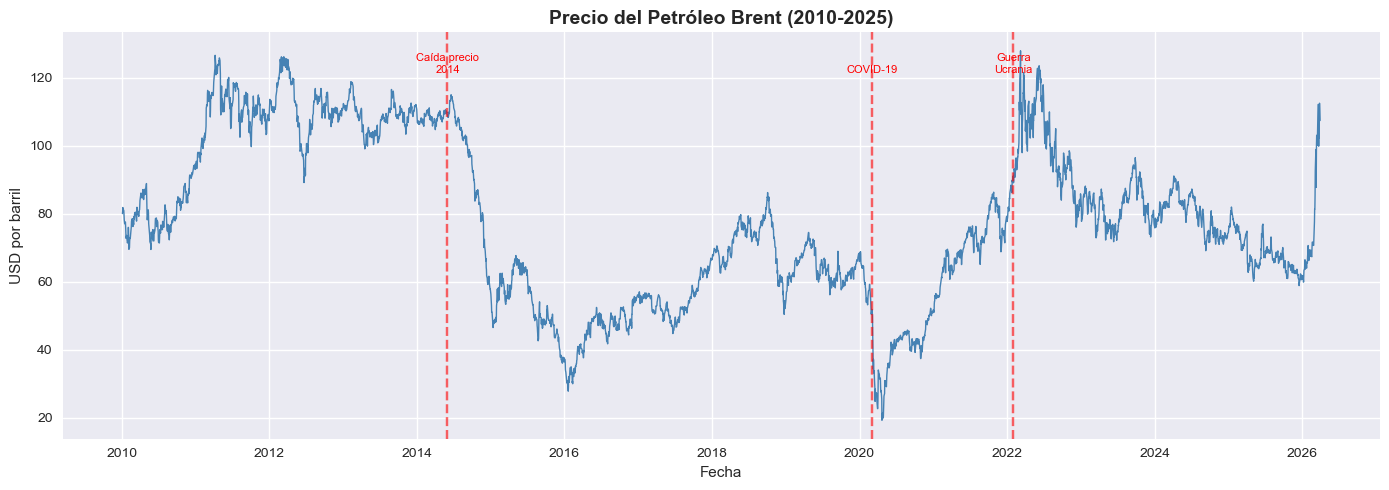

Gráfico guardado en outputs/


In [7]:
# Graficar la serie del Brent
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(brent.index, brent["precio_brent"], color="steelblue", linewidth=1)

ax.set_title("Precio del Petróleo Brent (2010-2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("USD por barril")

# Marcar eventos clave
eventos = {
    "2014-06": "Caída precio\n2014",
    "2020-03": "COVID-19",
    "2022-02": "Guerra\nUcrania"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), brent["precio_brent"].max() * 0.95,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/01_serie_brent.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")

In [8]:
# Descargar tipo de cambio oficial ARS/USD desde la API del BCRA
import requests

url = "https://api.bcra.gob.ar/estadisticas/v3.0/monetarias/1/2010-01-01/2025-12-31"

headers = {"accept": "application/json"}

response = requests.get(url, headers=headers, verify=False)
data = response.json()

# Convertir a DataFrame
tcn = pd.DataFrame(data["results"])
tcn["fecha"] = pd.to_datetime(tcn["fecha"])
tcn = tcn.set_index("fecha")
tcn.columns = ["tipo_cambio"]
tcn["tipo_cambio"] = pd.to_numeric(tcn["tipo_cambio"])
tcn = tcn.sort_index()

print(f"Datos descargados: {len(tcn)} observaciones")
print(f"Período: {tcn.index[0].date()} al {tcn.index[-1].date()}")
tcn.tail()

C:\Users\facun\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [9]:
pip install bcraapi

Note: you may need to restart the kernel to use updated packages.


In [15]:
import requests
import urllib3
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://api.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD"
params = {"fechadesde": "2010-01-01", "fechahasta": "2025-12-31"}

response = requests.get(url, params=params, verify=False)
data = response.json()

# Desanidar usando el campo correcto
registros = []
for item in data["results"]:
    fecha = item["fecha"]
    for detalle in item["detalle"]:
        if detalle["codigoMoneda"] == "USD":
            registros.append({
                "fecha": fecha,
                "tipo_cambio": detalle["tipoCotizacion"]
            })

tcn = pd.DataFrame(registros)
tcn["fecha"] = pd.to_datetime(tcn["fecha"])
tcn = tcn.set_index("fecha")
tcn["tipo_cambio"] = pd.to_numeric(tcn["tipo_cambio"])
tcn = tcn.sort_index()

print(f"Datos descargados: {len(tcn)} observaciones")
print(f"Período: {tcn.index[0].date()} al {tcn.index[-1].date()}")
tcn.tail()

Datos descargados: 1000 observaciones
Período: 2021-11-23 al 2025-12-31


,tipo_cambio
fecha,
2025-12-23,1451.00
2025-12-26,1452.50
2025-12-29,1457.00
2025-12-30,1455.00
2025-12-31,1455.00


In [14]:
# Inspeccionar estructura de un registro
print(data["results"][0])

{'fecha': '2025-12-31', 'detalle': [{'codigoMoneda': 'USD', 'descripcion': 'DOLAR E.E.U.U.', 'tipoPase': 0.0, 'tipoCotizacion': 1455.0}]}


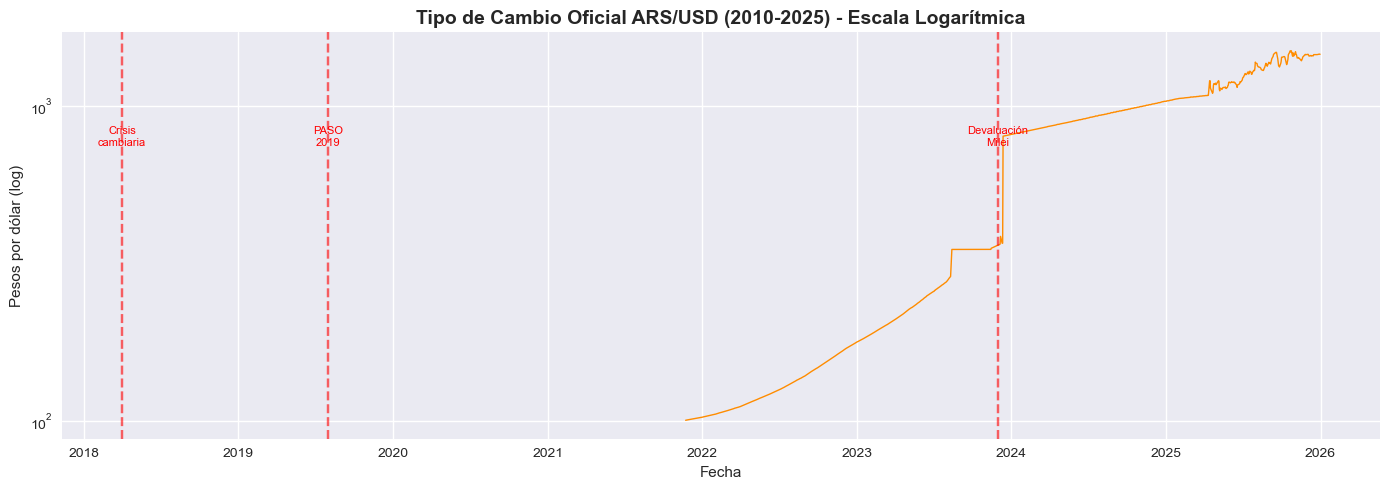

Gráfico guardado en outputs/


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tcn.index, tcn["tipo_cambio"], color="darkorange", linewidth=1)

ax.set_yscale("log")  # Escala logarítmica

ax.set_title("Tipo de Cambio Oficial ARS/USD (2010-2025) - Escala Logarítmica", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pesos por dólar (log)")

# Marcar eventos clave
eventos = {
    "2018-04": "Crisis\ncambiaria",
    "2019-08": "PASO\n2019",
    "2023-12": "Devaluación\nMilei"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), tcn["tipo_cambio"].max() * 0.5,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/02_serie_tipo_cambio.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")

In [19]:
# Descargar tipo de cambio ARS/USD desde yfinance
tcn_historico = yf.download("ARS=X", start="2010-01-01", end="2025-12-31")
tcn_historico = tcn_historico[["Close"]].copy()
tcn_historico.columns = ["tipo_cambio"]
tcn_historico = tcn_historico.sort_index()

print(f"Datos descargados: {len(tcn_historico)} observaciones")
print(f"Período: {tcn_historico.index[0].date()} al {tcn_historico.index[-1].date()}")
tcn_historico.tail()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 4163 observaciones
Período: 2010-01-01 al 2025-12-30


,tipo_cambio
Date,
2025-12-23,1451.72
2025-12-24,1450.16
2025-12-26,1449.58
2025-12-29,1450.50
2025-12-30,1457.01


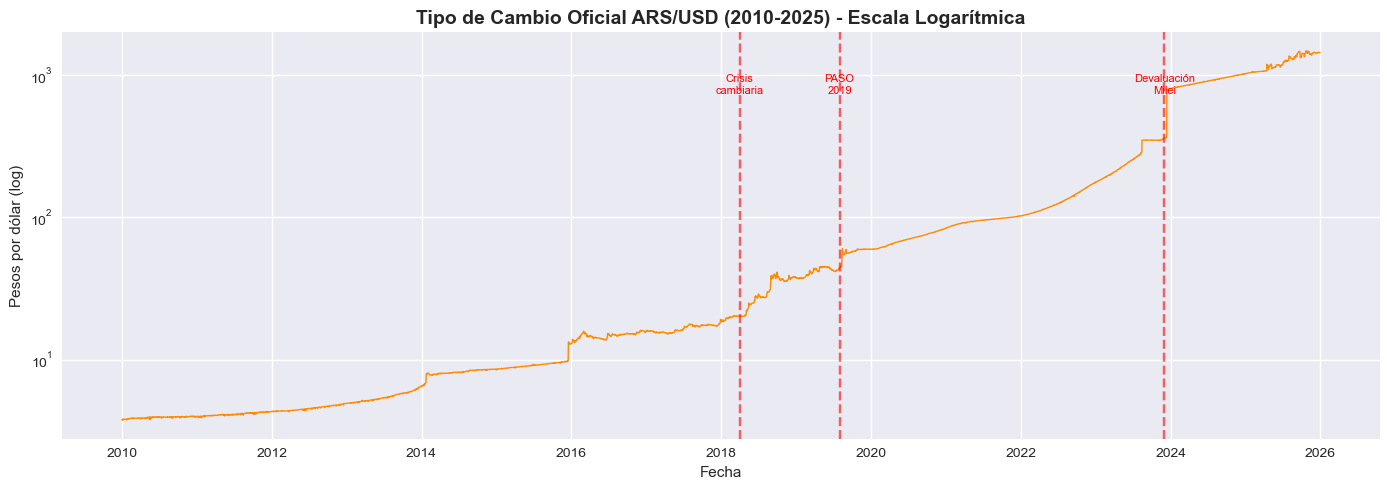

Gráfico guardado en outputs/


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tcn_historico.index, tcn_historico["tipo_cambio"], color="darkorange", linewidth=1)

ax.set_yscale("log")

ax.set_title("Tipo de Cambio Oficial ARS/USD (2010-2025) - Escala Logarítmica", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pesos por dólar (log)")

eventos = {
    "2018-04": "Crisis\ncambiaria",
    "2019-08": "PASO\n2019",
    "2023-12": "Devaluación\nMilei"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), tcn_historico["tipo_cambio"].max() * 0.5,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/02_serie_tipo_cambio.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")